In [1]:
#Lib Imports 
import pandas as pd
import numpy as np
import warnings

# ignorar todos los warnings
warnings.filterwarnings('ignore')


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn_pandas import DataFrameMapper
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


from tensorflow.keras.models import Sequential, clone_model,save_model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import Callback,EarlyStopping
from tensorflow.keras.optimizers import Adam



In [2]:

# cargamos el dataset principal con datos historicos y variables externas
df = pd.read_csv("../data/full_data.csv", parse_dates=["Date"], dayfirst=False)

# ordenamos por fecha
df = df.sort_values("Date").reset_index(drop=True)

# mostramos info general del dataset
print("columnas disponibles:")
print(df.columns.tolist())

print("\nprimeras filas:")
print(df.tail()) #Vemos los ultimos datos

print("\ntipos de datos:")
print(df.dtypes)


columnas disponibles:
['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Daily_Change', 'Volatility', 'Pct_Change', 'Volume_Change_pct', 'SMA_7', 'SMA_30', 'Rolling_volatility_7', 'Rolling_volatility_30', 'BTC_Close_t-1', 'BTC_Close_t-2', 'BTC_Close_t-3', 'BTC_Close_t-7', 'fng_value', 'fng_classification', 'fng_diff_day', 'fng_SMA_7', 'fng_SMA_30', 'fng_trend', 'Is_Halving_Date', 'Block_reward']

primeras filas:
           Date         Close          Open          High           Low  \
3122 2026-08-20  73032.757812  69268.250000  73369.804688  68867.531250   
3123 2026-08-21  78335.187500  73031.085938  79463.710938  73011.414062   
3124 2026-08-22  77083.414062  78332.554688  78801.148438  76526.710938   
3125 2026-08-23  77755.265625  77082.843750  78036.867188  75624.945312   
3126 2026-08-24  78858.929688  77727.617188  79891.304688  76838.726562   

           Volume  Daily_Change   Volatility  Pct_Change  Volume_Change_pct  \
3122  55444322363   3764.507812  4502.273438    0.054

In [3]:
# generacion de targets y analisis de correlacion

# generamos los 7 targets (precio de cierre futuro)
for i in range(1, 8):
    df[f"Close_t+{i}"] = df["Close"].shift(-i)

# eliminamos las filas sin datos completos (las ultimas 7)
df = df.dropna(subset=[f"Close_t+{i}" for i in range(1, 8)]).reset_index(drop=True)

# definimos las features numericas disponibles (todas menos las categoricas o de texto)
available_features = [col for col in df.columns if df[col].dtype != "object" and col not in [f"Close_t+{i}" for i in range(1, 8)]]

# lista de targets
targets = [f"Close_t+{i}" for i in range(1, 8)]


In [4]:
# seleccion de features mas correlacionadas

selected_features = ['Date','Volume','Pct_Change','Volume_Change_pct','Volatility','SMA_7','SMA_30',
             'fng_value','fng_SMA_7','fng_SMA_30','BTC_Close_t-1','BTC_Close_t-2','BTC_Close_t-3','BTC_Close_t-7','Rolling_volatility_30', 'Block_reward'] ##Agrego dos features más *Nota interna: menos es más*


# dejamos solo las columnas seleccionadas y los 7 targets
keep_cols = selected_features + [f"Close_t+{i}" for i in range(1, 8)]
df = df[keep_cols].copy()

print(f"dataset final listo para entrenamiento, con {len(selected_features)} features y 7 targets\n")
print(df.head())


dataset final listo para entrenamiento, con 16 features y 7 targets

        Date       Volume  Pct_Change  Volume_Change_pct   Volatility  SMA_7  \
0 2018-02-01   9959400448         NaN                NaN  1476.519531    NaN   
1 2018-02-02  12726899712   -0.037052           0.277878  1345.790039    NaN   
2 2018-02-03   7263790080    0.038973          -0.429257  1179.120117    NaN   
3 2018-02-04   7073549824   -0.097865          -0.026190  1303.649902    NaN   
4 2018-02-05   9285289984   -0.159688           0.312678  1608.159668    NaN   

   SMA_30  fng_value  fng_SMA_7  fng_SMA_30  ...  BTC_Close_t-7  \
0     NaN       30.0        NaN         NaN  ...            NaN   
1     NaN       15.0        NaN         NaN  ...            NaN   
2     NaN       40.0        NaN         NaN  ...            NaN   
3     NaN       24.0        NaN         NaN  ...            NaN   
4     NaN       11.0        NaN         NaN  ...            NaN   

   Rolling_volatility_30  Block_reward    Close

In [5]:
# features: todas las columnas numericas excepto los targets y la fecha
targets = [f"Close_t+{i}" for i in range(1, 8)]
features = [c for c in df.columns if c not in targets + ["Date"]]

# diccionarios para guardar X e Y por horizonte
X_dict = {}
Y_dict = {}

for i in range(1, 8):
    tcol = f"Close_t+{i}"
    X_dict[i] = df[features].copy()
    Y_dict[i] = df[[tcol]].copy()

# mostrar shapes para confirmar
print("resumen de shapes por horizonte (i -> X.shape -> y.shape):\n")
for i in range(1, 8):
    print(f"t+{i}: X {X_dict[i].shape} -> Y {Y_dict[i].shape}")

# ejemplo: mostrar las primeras filas del horizonte 1
print("\nprimeras filas - ejemplo horizonte t+1 (X, Y):")
print(X_dict[1].head())
print(Y_dict[1].head())


resumen de shapes por horizonte (i -> X.shape -> y.shape):

t+1: X (3120, 15) -> Y (3120, 1)
t+2: X (3120, 15) -> Y (3120, 1)
t+3: X (3120, 15) -> Y (3120, 1)
t+4: X (3120, 15) -> Y (3120, 1)
t+5: X (3120, 15) -> Y (3120, 1)
t+6: X (3120, 15) -> Y (3120, 1)
t+7: X (3120, 15) -> Y (3120, 1)

primeras filas - ejemplo horizonte t+1 (X, Y):
        Volume  Pct_Change  Volume_Change_pct   Volatility  SMA_7  SMA_30  \
0   9959400448         NaN                NaN  1476.519531    NaN     NaN   
1  12726899712   -0.037052           0.277878  1345.790039    NaN     NaN   
2   7263790080    0.038973          -0.429257  1179.120117    NaN     NaN   
3   7073549824   -0.097865          -0.026190  1303.649902    NaN     NaN   
4   9285289984   -0.159688           0.312678  1608.159668    NaN     NaN   

   fng_value  fng_SMA_7  fng_SMA_30  BTC_Close_t-1  BTC_Close_t-2  \
0       30.0        NaN         NaN            NaN            NaN   
1       15.0        NaN         NaN    9170.540039          

In [6]:

#targets y features
targets = [f"Close_t+{i}" for i in range(1, 8)]  # 7 targets, 7 modelos
features = [col for col in df.columns if col not in targets + ['Date']]  # usamos todas las features excepto targets y date

#columnas a escalar
cols_scaler = features  # todas las numericas

#crear mapper
# mapper aplica: primero imputa valores nulos con la mediana, luego escala con robust scaler
mapper = DataFrameMapper([
    (cols_scaler, [SimpleImputer(strategy='median'), RobustScaler()])
], input_df=True, df_out=True)

#definir modelo  --- Juego con los HiperParametros
models_dict = {
    "LinearRegression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=15),
    "DecisionTree": DecisionTreeRegressor(max_depth=None, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

#pipelines vacios por cada target
pipelines = {}
for target in targets:
    # aca solo definimos el pipeline base, luego le metemos cada modelo de la lista, 28 pipelines
    pipelines[target] = {}
    
    for model_name, model in models_dict.items():
        pipeline = Pipeline([
            ('mapper', mapper),
            ('model', model)
        ])
        pipelines[target][model_name] = pipeline


In [7]:

# definimos tamaño de test final
test_size = 0.15 #Aumento un poco más el tamaño para test
n_test = int(len(df) * test_size)

# separamos test final
train_val_df = df.iloc[:-n_test].reset_index(drop=True)
test_df = df.iloc[-n_test:].reset_index(drop=True)

n_splits = 6
tscv = TimeSeriesSplit(n_splits=n_splits)

# diccionarios para guardar índices por fold y por target
folds_idx = {target: [] for target in targets}

print(f"División en {n_splits} folds (train/val) por fechas:\n")
for target in targets:
    print(f" Target: {target}")
    X = train_val_df[features]
    y = train_val_df[[target]]

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        # guardar indices
        folds_idx[target].append((train_idx, val_idx))

        # fechas para mostrar
        start_train = train_val_df.iloc[train_idx[0]]['Date']
        end_train   = train_val_df.iloc[train_idx[-1]]['Date']
        start_val   = train_val_df.iloc[val_idx[0]]['Date']
        end_val     = train_val_df.iloc[val_idx[-1]]['Date']

        print(f"Fold {fold+1}:")
        print(f"  Train: {start_train.date()} -> {end_train.date()} ({len(train_idx)} filas)")
        print(f"  Val:   {start_val.date()} -> {end_val.date()} ({len(val_idx)} filas)\n")

# mostrar tamaño test final
print(f"Test final: {test_df['Date'].min().date()} -> {test_df['Date'].max().date()} ({len(test_df)} filas)")


División en 6 folds (train/val) por fechas:

 Target: Close_t+1
Fold 1:
  Train: 2018-02-01 -> 2019-02-19 (384 filas)
  Val:   2019-02-20 -> 2020-03-03 (378 filas)

Fold 2:
  Train: 2018-02-01 -> 2020-03-03 (762 filas)
  Val:   2020-03-04 -> 2021-03-16 (378 filas)

Fold 3:
  Train: 2018-02-01 -> 2021-03-16 (1140 filas)
  Val:   2021-03-17 -> 2022-03-29 (378 filas)

Fold 4:
  Train: 2018-02-01 -> 2022-03-29 (1518 filas)
  Val:   2022-03-30 -> 2023-04-11 (378 filas)

Fold 5:
  Train: 2018-02-01 -> 2023-04-11 (1896 filas)
  Val:   2023-04-12 -> 2024-04-23 (378 filas)

Fold 6:
  Train: 2018-02-01 -> 2024-04-23 (2274 filas)
  Val:   2024-04-24 -> 2025-05-06 (378 filas)

 Target: Close_t+2
Fold 1:
  Train: 2018-02-01 -> 2019-02-19 (384 filas)
  Val:   2019-02-20 -> 2020-03-03 (378 filas)

Fold 2:
  Train: 2018-02-01 -> 2020-03-03 (762 filas)
  Val:   2020-03-04 -> 2021-03-16 (378 filas)

Fold 3:
  Train: 2018-02-01 -> 2021-03-16 (1140 filas)
  Val:   2021-03-17 -> 2022-03-29 (378 filas)

Fol

In [8]:

n_splits = 7
tscv = TimeSeriesSplit(n_splits=n_splits)

# diccionario para resultados
cv_results = {}  # {target: {model_name: [fold_results]}}

for target in targets:
    print(f"\n Target: {target}")
    X = df[features]
    y = df[[target]]

    cv_results[target] = {}

    for model_name, pipeline in pipelines[target].items():
        print(f"\n Modelo: {model_name}")
        fold_results = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            # entrenar
            pipeline.fit(X_train, y_train)

            # predecir
            y_pred_train = pipeline.predict(X_train)
            y_pred_val   = pipeline.predict(X_val)

            # métricas
            mae_train = mean_absolute_error(y_train, y_pred_train)
            rmse_train = mean_squared_error(y_train, y_pred_train)**0.5

            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = mean_squared_error(y_val, y_pred_val)**0.5

            fold_results.append({
                "fold": fold+1,
                "MAE_train": mae_train, "RMSE_train": rmse_train,
                "MAE_val": mae_val, "RMSE_val": rmse_val
            })

            print(f"Fold {fold+1}: Train MAE {mae_train:.2f}, RMSE {rmse_train:.2f} | "
                  f"Val MAE {mae_val:.2f}, RMSE {rmse_val:.2f}")

        cv_results[target][model_name] = fold_results



 Target: Close_t+1

 Modelo: LinearRegression
Fold 1: Train MAE 192.96, RMSE 290.03 | Val MAE 419.68, RMSE 583.08
Fold 2: Train MAE 211.56, RMSE 330.73 | Val MAE 804.16, RMSE 1456.22
Fold 3: Train MAE 414.70, RMSE 792.06 | Val MAE 1773.34, RMSE 2297.27
Fold 4: Train MAE 749.85, RMSE 1219.91 | Val MAE 476.71, RMSE 707.88
Fold 5: Train MAE 697.85, RMSE 1137.62 | Val MAE 892.94, RMSE 1417.27
Fold 6: Train MAE 743.07, RMSE 1207.51 | Val MAE 1926.72, RMSE 2563.86
Fold 7: Train MAE 923.37, RMSE 1484.93 | Val MAE 1649.63, RMSE 2254.11

 Modelo: KNN
Fold 1: Train MAE 314.52, RMSE 481.35 | Val MAE 964.48, RMSE 1167.22
Fold 2: Train MAE 317.74, RMSE 494.33 | Val MAE 11580.71, RMSE 20046.51
Fold 3: Train MAE 549.19, RMSE 1058.51 | Val MAE 3695.47, RMSE 4536.79
Fold 4: Train MAE 1436.37, RMSE 2199.37 | Val MAE 8266.46, RMSE 9252.58
Fold 5: Train MAE 1296.46, RMSE 1975.41 | Val MAE 4450.65, RMSE 5678.23
Fold 6: Train MAE 1520.00, RMSE 2293.62 | Val MAE 22846.12, RMSE 27201.64
Fold 7: Train MAE 191

In [9]:

# features y targets ya definidos

# diccionario para guardar pesos por fold/epoch
model_weights_by_horizon = {}

# Callback para guardar pesos
class OurCustomCallback(Callback):
    def __init__(self, horizon):
        super().__init__()
        self.horizon = horizon
        
    def on_epoch_end(self, epoch, logs=None):
        import copy
        if self.horizon not in model_weights_by_horizon:
            model_weights_by_horizon[self.horizon] = {}
        model_weights_by_horizon[self.horizon][epoch] = copy.deepcopy(self.model.get_weights())

# función para crear un modelo base
def create_mlp_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.1),
        Dense(128, activation='relu'), #Cambio la activacion de relu a elu
        Dense(64, activation='relu'),
        Dense(1, activation='linear')  # salida para un solo target
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae','mse'])
    return model


In [10]:

# para guardar resultados
cv_results_nn = {}

# escalador
scaler = RobustScaler()

# early stopping para evitar sobreajuste
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for i, target in enumerate(targets, start=1):
    print(f"\n Entrenando modelo NN para {target}")
    cv_results_nn[target] = []

    X = train_val_df[features].values
    y = train_val_df[[target]].values

    for fold, (train_idx, val_idx) in enumerate(folds_idx[target]):
        print(f"\n Fold {fold+1}/{len(folds_idx[target])}")

        # separar sets
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]


        # Se reemplazó por valores NaN
        imputer = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_train)
        X_val_imp   = imputer.transform(X_val)
        X_train_scaled = scaler.fit_transform(X_train_imp)
        X_val_scaled   = scaler.transform(X_val_imp)


        # crear nuevo modelo
        model = create_mlp_model(X_train_scaled.shape[1])

        # callback personalizado (opcional)
        callback = OurCustomCallback(horizon=i)

        # entrenar
        history = model.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=150,
            batch_size=32,
            verbose=0
        )

        # predicciones
        y_pred_train = model.predict(X_train_scaled)
        y_pred_val = model.predict(X_val_scaled)

        # métricas
        mae_train = mean_absolute_error(y_train, y_pred_train)
        rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
        mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

        mae_val = mean_absolute_error(y_val, y_pred_val)
        rmse_val = mean_squared_error(y_val, y_pred_val) ** 0.5
        mape_val = mean_absolute_percentage_error(y_val, y_pred_val)

        print(
            f"Fold {fold+1}: "
            f"Train -> MAE={mae_train:.4f}, RMSE={rmse_train:.4f} | "
            f"Val -> MAE={mae_val:.4f}, RMSE={rmse_val:.4f}"
        )

        # guardar resultados
        cv_results_nn[target].append({
            'fold': fold+1,
            'MAE_train': mae_train,
            'RMSE_train': rmse_train,
            'MAPE_train': mape_train,
            'MAE_val': mae_val,
            'RMSE_val': rmse_val,
            'MAPE_val': mape_val
        })

# promedio final por target
print("\n Resultados Promedio por Horizonte")
for target in targets:
    mae_train_mean = np.mean([r['MAE_train'] for r in cv_results_nn[target]])
    mae_val_mean = np.mean([r['MAE_val'] for r in cv_results_nn[target]])
    rmse_train_mean = np.mean([r['RMSE_train'] for r in cv_results_nn[target]])
    rmse_val_mean = np.mean([r['RMSE_val'] for r in cv_results_nn[target]])

    print(
        f"{target}: "
        f"Train -> MAE={mae_train_mean:.4f}, RMSE={rmse_train_mean:.4f} | "
        f"Val -> MAE={mae_val_mean:.4f}, RMSE={rmse_val_mean:.4f}"
    )



 Entrenando modelo NN para Close_t+1

 Fold 1/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Fold 1: Train -> MAE=241.9669, RMSE=327.4712 | Val -> MAE=2877.0119, RMSE=3829.5905

 Fold 2/6
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fold 2: Train -> MAE=200.6132, RMSE=292.0585 | Val -> MAE=1062.8069, RMSE=1676.0126

 Fold 3/6
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 3: Train -> MAE=403.3303, RMSE=773.3421 | Val -> MAE=1661.7871, RMSE=2144.8551

 Fold 4/6
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4: Train -> MAE=726.4692, RMSE=1258.3415 | Val -> MAE=763.2328, RMSE=1024.0700

 Fold 5/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 5: Train -> MAE=907.0440, RMSE=1411.9442 | Val -> MAE=1366.4452, RMSE=1917.6598

 Fold 6/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

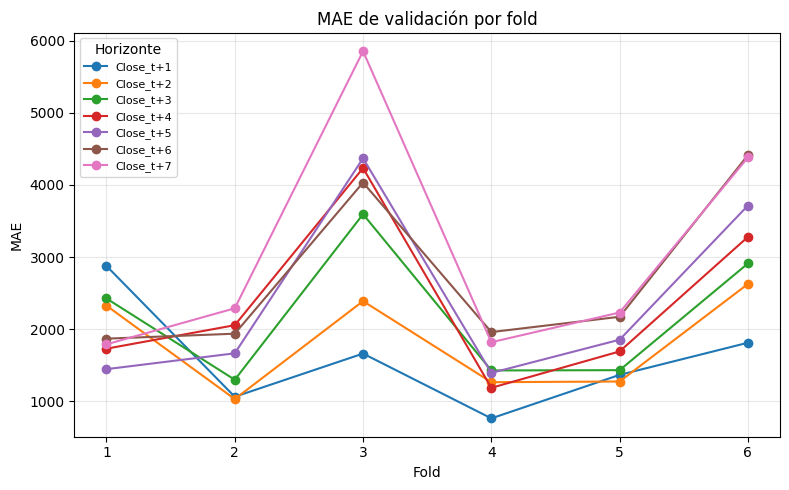

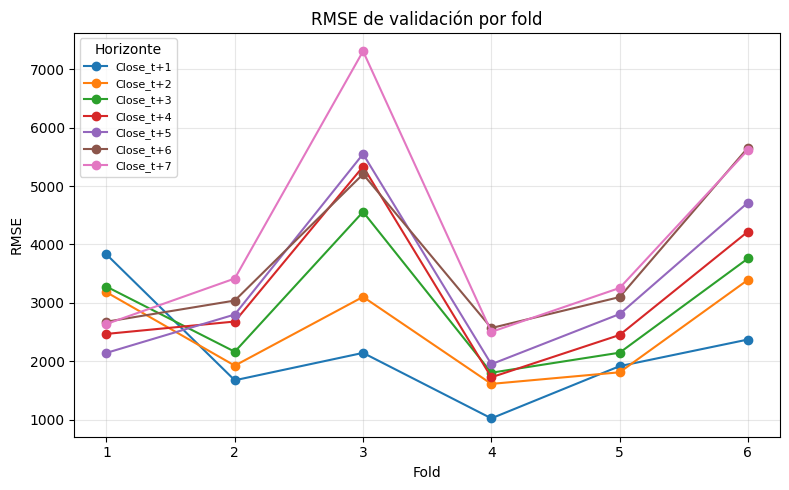

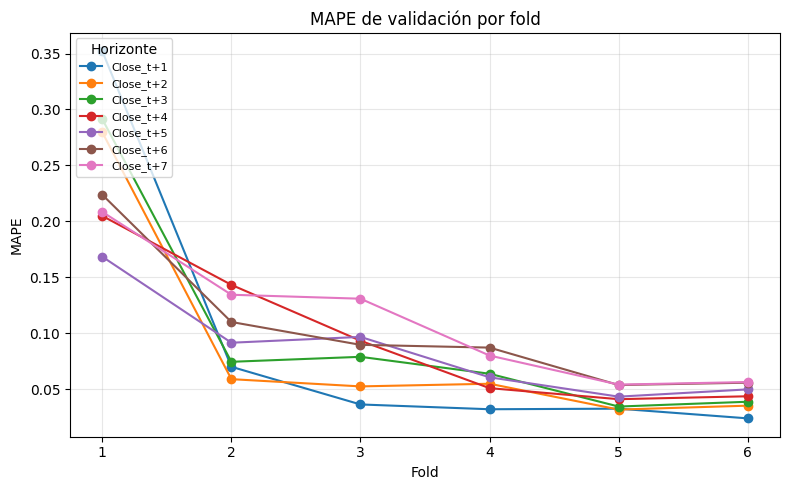

In [15]:
import matplotlib.pyplot as plt

# armamos un DataFrame unico con las metricas de validacion por fold y horizonte
cv_rows = []
for target, fold_results in cv_results_nn.items():
    for r in fold_results:
        cv_rows.append({
            "target": target,
            "fold": r["fold"],
            "MAE_val": r["MAE_val"],
            "RMSE_val": r["RMSE_val"],
            "MAPE_val": r["MAPE_val"],
        })
cv_metrics_df = pd.DataFrame(cv_rows)

metrics = [("MAE_val", "MAE"), ("RMSE_val", "RMSE"), ("MAPE_val", "MAPE")]

for col, label in metrics:
    plt.figure(figsize=(8, 5))
    for target in targets:
        subset = cv_metrics_df[cv_metrics_df["target"] == target]
        plt.plot(subset["fold"], subset[col], marker="o", label=target)
    plt.title(f"{label} de validación por fold")
    plt.xlabel("Fold")
    plt.ylabel(label)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Horizonte", fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()



## Exploración de hiperparámetros (MLP)

Antes de entrenar los modelos finales, exploramos una grilla acotada de hiperparámetros de la red neuronal (arquitectura, dropout, learning rate y batch size). Para no disparar el tiempo de entrenamiento, la búsqueda se hace sobre un único horizonte representativo (*Close_t+1*) y el último fold de TimeSeriesSplit (el más parecido a un escenario real de producción, con el train más grande y el val más reciente).

La mejor combinación encontrada (menor *MAE_val*) es la que se usa como referencia para el modelo.


In [11]:

from itertools import product

# grilla de hiperparametros a explorar (acotada para no disparar el tiempo de entrenamiento)
param_grid = {
    "hidden_layers": [(128, 128, 64), (64, 64), (128, 64, 32)],
    "dropout": [0.0, 0.1, 0.2], 
    "learning_rate": [0.001, 0.0005,0.01],
    "batch_size": [16, 32,64],
}

def create_mlp_model_hp(input_dim, hidden_layers, dropout, learning_rate):
    model = Sequential([Input(shape=(input_dim,))])
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

# para acotar el tiempo de busqueda, exploramos sobre un unico horizonte representativo (t+1)
# y el ultimo fold (el mas parecido a un escenario real de produccion)
search_target = "Close_t+1"
search_train_idx, search_val_idx = folds_idx[search_target][-1]

X_search = train_val_df[features].values
y_search = train_val_df[[search_target]].values

X_train_hp, X_val_hp = X_search[search_train_idx], X_search[search_val_idx]
y_train_hp, y_val_hp = y_search[search_train_idx], y_search[search_val_idx]

imputer_hp = SimpleImputer(strategy='median')
X_train_hp_imp = imputer_hp.fit_transform(X_train_hp)
X_val_hp_imp = imputer_hp.transform(X_val_hp)

scaler_hp = RobustScaler()
X_train_hp_scaled = scaler_hp.fit_transform(X_train_hp_imp)
X_val_hp_scaled = scaler_hp.transform(X_val_hp_imp)

early_stop_hp = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hp_search_results = []
combinations = list(product(
    param_grid["hidden_layers"],
    param_grid["dropout"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
))

print(f"Explorando {len(combinations)} combinaciones de hiperparametros sobre {search_target} (ultimo fold)...\n")

for hidden_layers, dropout, learning_rate, batch_size in combinations:
    model = create_mlp_model_hp(X_train_hp_scaled.shape[1], hidden_layers, dropout, learning_rate)

    model.fit(
        X_train_hp_scaled, y_train_hp,
        validation_data=(X_val_hp_scaled, y_val_hp),
        epochs=80,
        batch_size=batch_size,
        callbacks=[early_stop_hp],
        verbose=0
    )

    y_pred_val_hp = model.predict(X_val_hp_scaled, verbose=0)
    mae_val = mean_absolute_error(y_val_hp, y_pred_val_hp)
    rmse_val = mean_squared_error(y_val_hp, y_pred_val_hp) ** 0.5

    hp_search_results.append({
        "hidden_layers": hidden_layers,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
    })

    print(f"layers={hidden_layers} | dropout={dropout} | lr={learning_rate} | batch={batch_size} "
          f"-> MAE_val={mae_val:.4f}, RMSE_val={rmse_val:.4f}")

hp_results_df = pd.DataFrame(hp_search_results).sort_values("MAE_val").reset_index(drop=True)
print("\nTop 5 combinaciones (ordenadas por MAE_val):")
print(hp_results_df.head())

best_hparams = hp_results_df.iloc[0].to_dict()
print(f"\nMejor combinacion encontrada: {best_hparams}")


Explorando 81 combinaciones de hiperparametros sobre Close_t+1 (ultimo fold)...

layers=(128, 128, 64) | dropout=0.0 | lr=0.001 | batch=16 -> MAE_val=2204.1730, RMSE_val=2828.7256
layers=(128, 128, 64) | dropout=0.0 | lr=0.001 | batch=32 -> MAE_val=2247.4644, RMSE_val=2898.3538
layers=(128, 128, 64) | dropout=0.0 | lr=0.001 | batch=64 -> MAE_val=2382.5792, RMSE_val=3015.1176
layers=(128, 128, 64) | dropout=0.0 | lr=0.0005 | batch=16 -> MAE_val=1901.1643, RMSE_val=2490.7113
layers=(128, 128, 64) | dropout=0.0 | lr=0.0005 | batch=32 -> MAE_val=2206.2160, RMSE_val=2841.9328
layers=(128, 128, 64) | dropout=0.0 | lr=0.0005 | batch=64 -> MAE_val=3038.9367, RMSE_val=3758.3487
layers=(128, 128, 64) | dropout=0.0 | lr=0.01 | batch=16 -> MAE_val=1735.6389, RMSE_val=2308.6662
layers=(128, 128, 64) | dropout=0.0 | lr=0.01 | batch=32 -> MAE_val=1829.4964, RMSE_val=2419.3696
layers=(128, 128, 64) | dropout=0.0 | lr=0.01 | batch=64 -> MAE_val=1736.7450, RMSE_val=2308.4533
layers=(128, 128, 64) | drop

In [12]:
import os
import joblib  # para guardar el scaler

# directorio para guardar modelos
output_dir = "./models_final"
os.makedirs(output_dir, exist_ok=True)

# diccionario para guardar modelos y resultados
final_models = {}
final_metrics = {}

# iterar sobre los 7 horizontes
for i, target in enumerate(targets, start=1):
    print(f"\n Entrenando modelo final para {target}")
    
    # X e y completos (train + val)
    X = train_val_df[features].values
    y = train_val_df[[target]].values

    # imputar NaN antes de escalar -- Evitar error NaN
    imputer_final = SimpleImputer(strategy='median')
    X_imp = imputer_final.fit_transform(X)
    # escalar
    scaler_final = RobustScaler()
    X_scaled = scaler_final.fit_transform(X_imp)
    
    # crear modelo
    model = create_mlp_model(X_scaled.shape[1])

    # entrenar
    history = model.fit(
        X_scaled, y,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    # predicciones sobre todo el dataset
    y_pred = model.predict(X_scaled)

    # calcular metricas
    mae = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred) ** 0.5
    mape = mean_absolute_percentage_error(y, y_pred)

    print(f"{target} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.4f}")

    model.save(os.path.join(output_dir, f"mlp_{target}.keras"))
    joblib.dump(scaler_final,  os.path.join(output_dir, f"scaler_{target}.pkl"))
    joblib.dump(imputer_final, os.path.join(output_dir, f"imputer_{target}.pkl"))
    print(f"artefactos guardados en {output_dir}")

    # guardar en diccionario para uso inmediato
    final_models[target] = {
        "model": model,
        "scaler": scaler_final
    }

    # guardar metricas
    final_metrics[target] = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

print("\n Todos los modelos finales, scalers y metricas guardados")
final_metrics[target] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}


 Entrenando modelo final para Close_t+1
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Close_t+1 -> MAE: 811.5649, RMSE: 1331.0736, MAPE: 0.0325
artefactos guardados en ./models_final

 Entrenando modelo final para Close_t+2
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Close_t+2 -> MAE: 1133.5385, RMSE: 1800.0716, MAPE: 0.0443
artefactos guardados en ./models_final

 Entrenando modelo final para Close_t+3
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Close_t+3 -> MAE: 1349.1364, RMSE: 2171.8756, MAPE: 0.0474
artefactos guardados en ./models_final

 Entrenando modelo final para Close_t+4
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Close_t+4 -> MAE: 1523.8981, RMSE: 2399.8600, MAPE: 0.0576
artefactos guardados en ./models_final

 Entrenando modelo final para Close_t+5
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Close_t+5 -> MAE: 1655.7970, RMSE: 2616.9007, MAPE: 0.0600
artefactos guardados en ./models_final

 Entrenando modelo final para Close_t+6
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Close_t+6 -> MAE: 1

In [13]:


# diccionario para guardar métricas de test
test_metrics = {}

for target in targets:
    print(f"\n Evaluando modelo en test para {target}")

    # obtener modelo y scaler desde final_models
    model = final_models[target]["model"]
    scaler = final_models[target]["scaler"]

    # preparar X e y de test
    X_test = test_df[features].values
    y_test = test_df[[target]].values
        
     # aplicar los mismos artefactos del train, sin refitear
    X_test_imp    = imputer_final.transform(X_test)
    X_test_scaled = scaler.transform(X_test_imp)

    # predecir
    y_pred_test = model.predict(X_test_scaled)

    # calcular métricas
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
    mape = mean_absolute_percentage_error(y_test, y_pred_test)

    print(f"{target} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.4f}")

    # guardar métricas
    test_metrics[target] = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

print("\n métricas finales sobre test")
for target, met in test_metrics.items():
    print(f"{target}: MAE={met['MAE']:.4f}, RMSE={met['RMSE']:.4f}, MAPE={met['MAPE']:.4f}")



 Evaluando modelo en test para Close_t+1


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+1 -> MAE: 1646.4033, RMSE: 2206.8415, MAPE: 0.0184

 Evaluando modelo en test para Close_t+2
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+2 -> MAE: 2246.1870, RMSE: 3008.1515, MAPE: 0.0259

 Evaluando modelo en test para Close_t+3
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+3 -> MAE: 2902.7863, RMSE: 3742.5977, MAPE: 0.0320

 Evaluando modelo en test para Close_t+4
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+4 -> MAE: 2843.0165, RMSE: 3814.7068, MAPE: 0.0322

 Evaluando modelo en test para Close_t+5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+5 -> MAE: 3213.3766, RMSE: 4304.7948, MAPE: 0.0372

 Evaluando modelo en test para Close_t+6
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+6 -> MAE: 3679.4282, RMSE: 4914.3603, MAPE: 0.0411

 Evaluando modelo en test para Close_t+7
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Close_t+7 -> MAE: 3824.8127, RMSE: 5068.1660, MAPE: 0.0441

 métricas finales sobre test
Close_t+1: MAE=1646.4033,